#### Langchain Starts
This notebook shows how to use `langchain_ollama` to connect LangChain to a locally running Ollama runtime at `http://localhost:11434`.
No OpenAI API key is needed; the model runs locally on your machine.

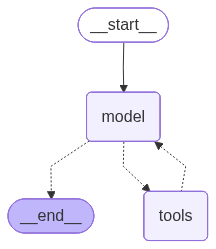

In [16]:
import os
from langchain.agents import create_agent
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2:3b",
    base_url=os.getenv("BASE_URL", "http://localhost:11434"),
    validate_model_on_init=False,
)

def get_weather(city: str):
    """Return a simple weather report for the requested city."""
    return f"The weather in {city} is sunny with a high of 25 degrees Celsius."

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant.",
)

agent


In [17]:
agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in New York?"}]}
)

{'messages': [HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='ea4d6afd-ef95-4316-849f-1bc150dbb4f7'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-06-04T19:44:00.8978298Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9309477200, 'load_duration': 5049156200, 'prompt_eval_count': 165, 'prompt_eval_duration': 2893789000, 'eval_count': 18, 'eval_duration': 1349777000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019e9429-d333-74e1-a1b9-316099b33fbf-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': '15f06cb6-270b-4d61-8e7a-eec8302aa358', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 18, 'total_tokens': 183}),
  ToolMessage(content='The weather in New York is sunny with a high of 25 degrees Celsius.', name='get_weather', id='2969c701-e4c5-4f

In [9]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the capital of India?"}]}
)

print(response)

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='1dfa91be-3dcc-4730-bd35-d2ad7f22cef2'), AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-06-04T18:34:32.0846886Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6049126200, 'load_duration': 4804184000, 'prompt_eval_count': 38, 'prompt_eval_duration': 708194000, 'eval_count': 9, 'eval_duration': 528808000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019e93ea-4394-7473-9770-f9943b3023bc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 9, 'total_tokens': 47})]}


In [10]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Give me the easiest example of a langchain agent?"}]}
)

print(response)

{'messages': [HumanMessage(content='Give me the easiest example of a langchain agent?', additional_kwargs={}, response_metadata={}, id='134824d8-f9bf-4154-ab81-700f163b0150'), AIMessage(content='A LangChain agent is an AI model that uses a combination of natural language processing (NLP) and external knowledge graphs to generate human-like responses. Here\'s a simple example of a LangChain agent:\n\n**Example: Book Recommendation Agent**\n\nImagine you want to build an agent that recommends books based on user preferences. The agent has the following components:\n\n1. **Textual Input**: The user provides their preferred book genre (e.g., "science fiction").\n2. **Knowledge Graph**: An external knowledge graph containing information about books, including genres, authors, and summaries.\n3. **NLP Model**: A machine learning model that processes the user\'s input and retrieves relevant book suggestions from the knowledge graph.\n\nHere\'s a high-level overview of how this agent works:\n\

In [20]:
response = llm.invoke("How are u ?")
response.content

"I'm just a language model, so I don't have feelings or emotions like humans do. However, I'm functioning properly and ready to assist you with any questions or tasks you may have! How can I help you today?"

In [21]:
response = llm.stream("How are u ?")
for chunk in response:
    print(chunk.content, end="", flush=True)    

I'm just a language model, so I don't have feelings or emotions like humans do. However, I'm functioning properly and ready to help with any questions or tasks you may have! How about you? How's your day going?

Streaming 
 streaming refers to two distinct but highly complementary concepts: delivering real-time event data to AI agents and generating AI responses in real-time (token-by-token)

In [24]:
response = llm.stream("Write a 200 word essay on the benefits of using langchain for building AI applications in hindi.")
for chunk in response:
    print(chunk.text, end="", flush=True)

लैंगचेन (LangChain) का उपयोग करने के लाभों पर एक निबंध:

लैंगचेन एक ऐसी टेक्नोलॉजी है जो मशीन लर्निंग मॉडल्स को बेहतर ढंग से परिचित कराने और उन्हें विभिन्न डेटा स्रोतों से जोड़ने में मदद करती है। इसके उपयोग से निम्नलिखित लाभ हैं:

अभिव्यक्ति की सीमाएं दूर करना: लैंगचेन का उपयोग करके, मशीन लर्निंग मॉडल्स को विभिन्न डेटा स्रोतों से जोड़ा जा सकता है, जिससे उनकी अभिव्यक्ति की सीमाएं दूर हो जाती हैं।
नई तकनीकों का उपयोग करना: लैंगचेन का उपयोग करके, मशीन लर्निंग मॉडल्स को नई तकनीकों से परिचित कराया जा सकता है, जिससे उनकी दक्षता बढ़ जाती है।
डेटा संग्रहण और प्रबंधन: लैंगचेन का उपयोग करके, मशीन लर्निंग मॉडल्स को विभिन्न डेटा स्रोतों से जोड़ा जा सकता है, जिससे उनकी दक्षता बढ़ जाती है और डेटा संग्रहण और प्रबंधन में मदद मिलती है।

कुल मिलाकर, लैंगचेन का उपयोग करने से मशीन लर्निंग मॉडल्स की दक्षता में वृद्धि होती है और उनकी अभिव्यक्ति की सीमाएं दूर हो जाती हैं।

Batch 
grouping data or tasks together so an autonomous AI agent can process them in bulk rather than handling them one by one

In [25]:
response = llm.batch([
    "what is the capital of india ?",
    "what is the quantum computing ?",
    "what the dark matter ?"
])

for res in response:
    print(res.content)

The capital of India is New Delhi.
Quantum computing is a new paradigm for computing that uses the principles of quantum mechanics to perform calculations and operations on data. It's different from classical computing, which uses bits to store and process information.

In classical computing, information is represented as 0s and 1s, which can be thought of as a coin that can either be heads (0) or tails (1). In contrast, quantum computers use qubits (quantum bits), which can exist in multiple states simultaneously, represented by a combination of 0s and 1s.

This property, known as superposition, allows quantum computers to process multiple possibilities at the same time, making them potentially much faster than classical computers for certain types of calculations. Quantum computers also use entanglement, which is a phenomenon where qubits can be connected in such a way that their states are correlated, allowing for fast communication and processing.

Quantum computing has many poten

In [27]:
from langchain_core.runnables import RunnableConfig


response = llm.batch(
    [
        "what is the capital of india ?",
        "what is the quantum computing ?",
        "what the dark matter ?"
    ],
    config=RunnableConfig(max_concurrency=2),
)

for res in response:
    print(res.content)


The capital of India is New Delhi.
Quantum Computing is a revolutionary new way of processing information that uses the principles of quantum mechanics to perform calculations and operations on data. It's a field that has the potential to solve problems that are currently unsolvable or require an unfeasible amount of time using classical computers.

Here's a brief overview:

**Classical Computing vs Quantum Computing**

Classical computers use bits, which can have a value of either 0 or 1. These bits are used to perform calculations and operations on data. However, as the size of the problem increases, classical computers become slower and more prone to errors.

Quantum computers, on the other hand, use quantum bits or qubits. Qubits can exist in multiple states simultaneously, which means they can process multiple possibilities at the same time. This allows quantum computers to perform certain calculations much faster than classical computers.

**Key Features of Quantum Computing**

1

we stopped at 1 hour